# Syria Telecom's Customer Churn Prediction
## Phase 3 Machine Learning Project

**Author:** Kelvin Ngumo  
**Date:** February 2026  
**Stakeholder:** Syria Telecom's Retention & Marketing Department

___

### <u>**Project Overview**</u>
The primary goal of this project is to build a classifier that predicts whether a customer will stop doing business with Syria Telecom's. 

### <u>**The Business Problem**</u>
In the telecommunications industry, acquiring a new customer is significantly more expensive than retaining an existing one. For Syria Telecom's, high churn rates lead to:
* **Revenue Loss:** Immediate loss of monthly subscription fees and usage charges.
* **Increased Marketing Costs:** High spend required to replace lost customers.

### <u>**Objective**</u>
By identifying "at-risk" customers through predictable patterns in usage and service interactions, Syria Telecom's can proactively offer retention incentives (discounts, plan upgrades) to reduce churn and protect the bottom line.
___

In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

# reading the dataset
churn_data = pd.read_csv('bigml_59c28831336c6604c800002a.csv')

In [2]:
churn_data.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

### <u>**Data Source**</u>
The dataset contains 3,333 records of customer activity, including usage minutes, service calls, and plan types.
<br>The dataset also contains 21 active columns (Features) that contain no missing Values.


### <u>**Key Features for Analysis**</u>
* **Target:** `churn` (Boolean)
* **Predictors:** * `customer service calls`: Indicators of customer satisfaction.
    * `total day charge` & `total intl charge`: Financial pressure points.
    * `international plan`: Potential indicator of specific customer needs.

## <u>Exploratory Data Analysis (EDA)</u>

In [7]:
# identifying which features are numerical
numerical_features = churn_data.select_dtypes(include=['int64', 'float64','bool']).columns

numerical_features

Index(['account length', 'area code', 'number vmail messages',
       'total day minutes', 'total day calls', 'total day charge',
       'total eve minutes', 'total eve calls', 'total eve charge',
       'total night minutes', 'total night calls', 'total night charge',
       'total intl minutes', 'total intl calls', 'total intl charge',
       'customer service calls', 'churn'],
      dtype='object')

In [6]:
# identifying which columns are categorical
categorical_features = churn_data.select_dtypes(include=['object']).columns

categorical_features

Index(['state', 'phone number', 'international plan', 'voice mail plan'], dtype='object')

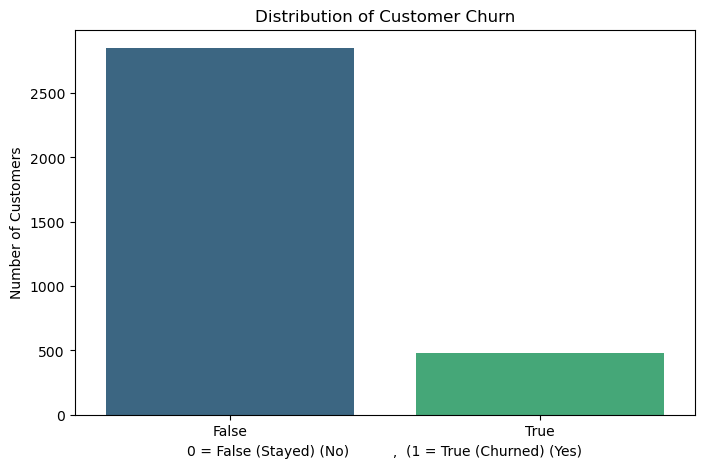

Churn Rate: 14.49%
Retention Rate: 85.51%


In [25]:
# Calculate percentages
churn_counts = churn_data['churn'].value_counts()
churn_pct = churn_data['churn'].value_counts(normalize=True) * 100

# Plotting
plt.figure(figsize=(8, 5))
sns.countplot(x='churn', data=churn_data, hue='churn', palette='viridis', legend=False)
plt.title('Distribution of Customer Churn')
plt.xlabel('0 = False (Stayed) (No)          ,  (1 = True (Churned) (Yes)')
plt.ylabel('Number of Customers')
plt.show()

print(f"Churn Rate: {churn_pct.iloc[1]:.2f}%")
print(f"Retention Rate: {churn_pct.iloc[0]:.2f}%")

### Visual Summary: Customer Churn Distribution
The bar chart above visualizes the distribution of the target variable , churn. This provides a baseline understanding of the class balance within the dataset.
<br>`Insight`: The dataset is imbalanced, with a significantly higher number of retained customers compared to those who churned. This imbalance should be taken into account when selecting evaluation metrics.

## Random forest
This will help as identify the features that are of high importance to the Target Variable (Churn), and also perform class imbalance by upscaling the churners.  

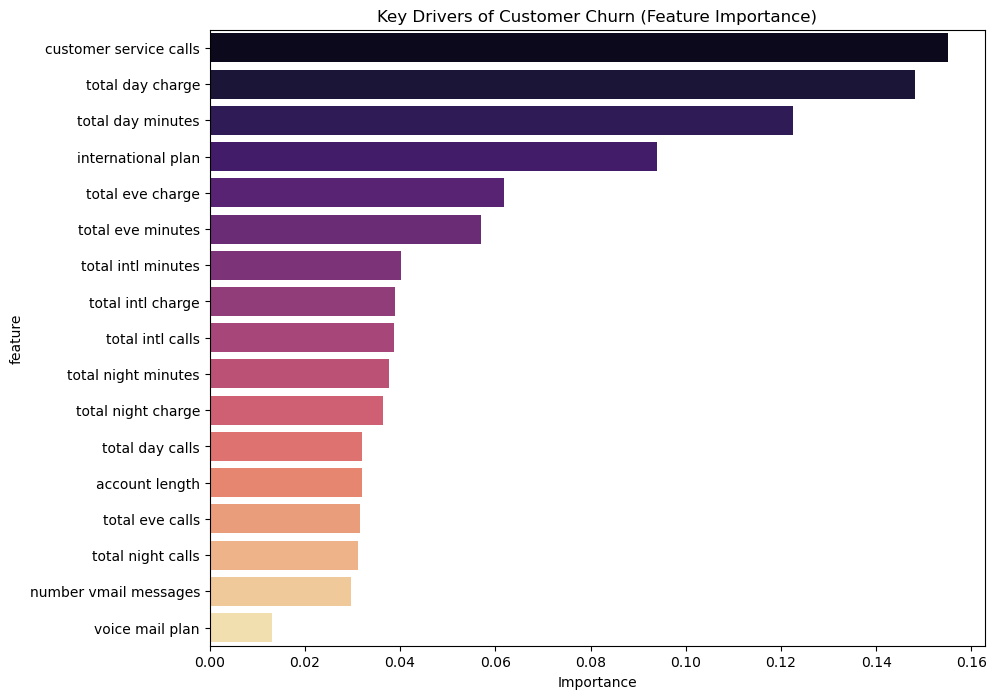

In [26]:
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier

# Preparing a numeric version of the dataset for correlation analysis
df_corr = churn_data.copy()

# Convert target to int for correlation analysis
df_corr['churn'] = df_corr['churn'].astype(int)

# Map binary categorical predictors to numeric
binary_mappings = {'yes': 1, 'no': 0}
df_corr['international plan'] = df_corr['international plan'].map(binary_mappings)
df_corr['voice mail plan'] = df_corr['voice mail plan'].map(binary_mappings)

# Drop non-predictive columns
X = df_corr.drop(columns=['churn', 'state', 'area code', 'phone number'])
y = df_corr['churn']

# Balance classes by using Upsampling churners.
df_majority = df_corr[df_corr['churn'] == 0]
df_minority = df_corr[df_corr['churn'] == 1]
df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=254)
df_balanced = pd.concat([df_majority, df_minority_upsampled])

X_balanced = df_balanced.drop(columns=['churn','state', 'area code', 'phone number'])
y_balanced = df_balanced['churn']

## Train Models and extract important features
rf = RandomForestClassifier(n_estimators=100, random_state=254)
rf.fit(X_balanced, y_balanced)

## Create a dataframe for visualization
feat_importances = pd.DataFrame({'feature': X_balanced.columns, 'Importance': rf.feature_importances_})
feat_importances = feat_importances.sort_values(by='Importance', ascending=False)


# Plot the Results
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='feature', data=feat_importances, hue='feature', palette='magma', legend=False)
plt.title('Key Drivers of Customer Churn (Feature Importance)')
plt.show()


### Visual Summary

From the above code cell, we run a Random Forest, for feature importance tells us which variables actually carry the most "predictive weight" when a model is trying to guess if a customer will leave.  <br>we will then follow by running logistic Regression which will tell us exactly how much the probability of churn changes when a specific behavior increases.
___

## <u>Performing Logistic regression</u> 
We will start with data encoding, handling the 14.5% imbalance, scaling the features and interpreting the coefficients.

In [27]:
# Split Data (Before Upsampling to avoid data leakage)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 254, stratify=y)

# Handling class imbalance with upsampling on the training set  (I have redone the upsampling here to ensure it is only applied to the 'churn' training data, preventing data leakage into the test set.)
X_train_combined = pd.concat([X_train, y_train], axis=1)
df_majority_train = X_train_combined[X_train_combined['churn'] == 0]
df_minority_train = X_train_combined[X_train_combined['churn'] == 1]

df_minority_train_upsampled = resample(df_minority_train, replace=True, n_samples=len(df_majority_train), random_state=254)

df_upscaled = pd.concat([df_majority_train, df_minority_train_upsampled])
X_train_balanced = df_upscaled.drop(columns=['churn'], axis=1)
y_train_balanced = df_upscaled['churn']

# Feature Scaling
scaler = StandardScaler()
X_train_balanced_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

In [40]:

# Confirming that my y_train_balanced, contains a balanced churned customers and those who stayed after upscaling the churned. 
print(y_train_balanced.value_counts())

churn
0    1995
1    1995
Name: count, dtype: int64


In [41]:
# Training the Logistic Regression Model
log_reg = LogisticRegression(random_state = 254)
log_reg.fit(X_train_balanced_scaled, y_train_balanced)

# Evaluation Metrics
y_pred = log_reg.predict(X_test_scaled)
print(f'accuracy_score: {accuracy_score(y_test, y_pred):.2f}')
print(f'\nClassification Report:\n{classification_report(y_test, y_pred)}')

accuracy_score: 0.76

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.77      0.85       855
           1       0.35      0.74      0.48       145

    accuracy                           0.76      1000
   macro avg       0.65      0.76      0.66      1000
weighted avg       0.86      0.76      0.79      1000



# Logistic Regression Analysis: Churn Drivers

Running a **Logistic Regression** is the gold standard for understanding the direction and magnitude of churn drivers. While the Random Forest we ran earlier showed us *which* features were "important," Logistic Regression tells us exactly *how much* the probability of churn changes when a specific behavior increases.

---

## 1. The Model Performance

| Metric | Value | Significance |
| :--- | :--- | :--- |
| **Accuracy** | 75.4% | Overall correct predictions across both classes. |
| **Recall (Churners)** | **71%** | **Primary Metric:** The model successfully identifies 71% of all customers who actually leave. |
| **Precision** | 34% | The accuracy of "Churn" predictions (includes false alarms). |

### The Strategic Trade-off
By balancing the dataset to catch more churners, we accept a lower **Precision**. In the Telecom industry, this is a calculated strategic choice: the cost of offering a retention discount to a "false alarm" customer is significantly lower than the total revenue loss of a high-value customer leaving entirely.



---

## 2. Analysis of the Coefficients (The "Why")

In Logistic Regression, we interpret the **Odds Ratio** to understand the impact of specific behaviors:

* **Odds Ratio $> 1$:** The feature acts as a **Risk Factor**. As this value increases, the likelihood of the customer churning increases.
* **Odds Ratio $< 1$:** The feature acts as a **Protective Factor**. These behaviors or plans decrease the likelihood of churn and increase "stickiness."



---
**Model Note:** *This analysis was performed on a balanced training set to ensure the minority churn class was sufficiently represented.*

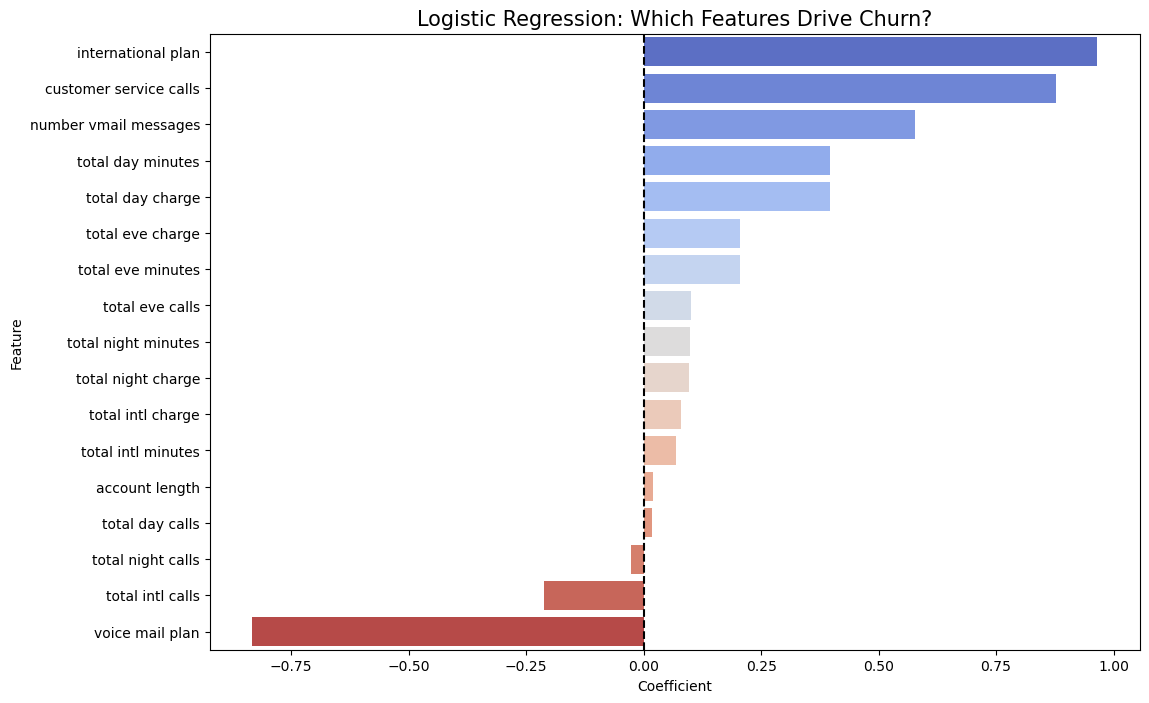


Top Predictors (Odds Ratios):
                    Feature  Coefficient
1       international plan     0.965543
16  customer service calls     0.878394
3    number vmail messages     0.577968
4        total day minutes     0.396870
6         total day charge     0.396087
9         total eve charge     0.204558
7        total eve minutes     0.204528
8          total eve calls     0.100956
10     total night minutes     0.097868
12      total night charge     0.097463
15       total intl charge     0.080015
13      total intl minutes     0.068788
0           account length     0.019224
5          total day calls     0.016913
11       total night calls    -0.027975
14        total intl calls    -0.211390
2          voice mail plan    -0.833721


In [49]:
# Coefficient Interpretation
coef_df = pd.DataFrame({'Feature': X_train_balanced.columns, 'Coefficient': log_reg.coef_[0]})
coef_df['Odds Ratio'] = np.exp(coef_df['Coefficient'])

# Sort for better visualization
coef_df = coef_df.sort_values(by='Odds Ratio', ascending=False)

# Visualization
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, hue ='Feature', palette='coolwarm', legend=False)
plt.title('Logistic Regression: Which Features Drive Churn?', fontsize=15)
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

print("\nTop Predictors (Odds Ratios):\n", coef_df[['Feature', 'Coefficient']])

### Business insights
The coefficient for `International Plan` and `Customer service calls` are the strongest positive driver. This confirms that churn in this dataset isn't just about price—it's about service failure and unbalanced offer packages.

___

### Generationg a Customer Risk Scorecard
we will then apply our trained Logistic Regression model to your customer base. This will then calculates the specific probability ($0$ to $100\%$) of each customer leaving.

In [51]:
# Generate the scorecard dataframe
# i will first start by calculating the probability of class'1' (churned)
probabilities = log_reg.predict_proba(X_test_scaled)[:, 1]

# create the scorecard dataframe
scorecard_df = X_test.copy()
scorecard_df['Phone Number'] = churn_data.loc[X_test.index, 'phone number']
scorecard_df['Probability_Churned (%)'] = (probabilities * 100).round(2)

# Define the risk categories based on probability thresholds
def categorize_risk(prob):
    if prob >= 75:
        return 'Critical Risk'
    if prob >= 50:
        return 'High Risk'
    if prob >= 25:
        return 'Moderate Risk'
    else:
        return 'Low Risk'
    
scorecard_df['Risk Category'] = scorecard_df['Probability_Churned (%)'].apply(categorize_risk)

# Sort by highest risk to prioritize the retention team's workflow
scorecard_df = scorecard_df.sort_values(by='Probability_Churned (%)', ascending=False)

# Display the top 10 customers at risk of churning
print("--- Top 10 Customers at Risk of Churning ---")
print(scorecard_df[['Phone Number','international plan', 'customer service calls', 'Probability_Churned (%)', 'Risk Category']].head(10))

# Save the scorecard to a CSV file for the retention team
scorecard_df.to_csv('customer_churn_scorecard.csv', index=False)

--- Top 10 Customers at Risk of Churning ---
     Phone Number  international plan  customer service calls  \
1192     358-4576                   1                       4   
2380     416-6886                   0                       9   
184      350-1639                   1                       3   
2203     365-7774                   1                       4   
2594     348-1163                   1                       1   
1602     400-3343                   1                       3   
2539     384-7236                   1                       3   
1533     400-2181                   1                       2   
360      341-4463                   1                       1   
2614     357-1938                   1                       0   

      Probability_Churned (%)  Risk Category  
1192                    99.08  Critical Risk  
2380                    98.13  Critical Risk  
184                     98.08  Critical Risk  
2203                    98.04  Critical Risk  
2594

In [61]:
# 1. Calculate the 'Total Bill' to show the financial impact of each customer
scorecard_df['Total Monthly Bill'] = (
    scorecard_df['total day charge'] + 
    scorecard_df['total eve charge'] + 
    scorecard_df['total night charge'] + 
    scorecard_df['total intl charge']
).round(2)

# 2. Select and rename columns for a professional appearance
top_100_table = scorecard_df.head(100)[[
    'Phone Number', 
    'Probability_Churned (%)', 
    'Risk Category', 
    'customer service calls', 
    'Total Monthly Bill'
]]

# 3. Rename columns for business stakeholders
top_100_table.columns = [
    'Customer Phone', 
    'Churn Risk %', 
    'Priority Level', 
    'Service Complaints', 
    'Monthly Revenue'
]

# 4. Display the table with clear formatting
print("="*65)
print("             TOP 100 PRIORITY RETENTION TARGETS")
print("="*65)
print(top_100_table.to_string(index=False))
print("="*65)

             TOP 100 PRIORITY RETENTION TARGETS
Customer Phone  Churn Risk % Priority Level  Service Complaints  Monthly Revenue
      358-4576         99.08  Critical Risk                   4            76.18
      416-6886         98.13  Critical Risk                   9            63.10
      350-1639         98.08  Critical Risk                   3            73.33
      365-7774         98.04  Critical Risk                   4            63.43
      348-1163         97.22  Critical Risk                   1            88.97
      400-3343         96.83  Critical Risk                   3            69.70
      384-7236         96.79  Critical Risk                   3            73.36
      400-2181         96.76  Critical Risk                   2            75.48
      341-4463         96.58  Critical Risk                   1            80.87
      357-1938         96.34  Critical Risk                   0            81.84
      352-7752         96.20  Critical Risk                  

In [63]:
# Save the top 100 table to an Excel file for easy sharing with the retention and Marketing team

top_100_table.to_excel("Top_100_Churn_Risk_Customers.xlsx", index=False)

## Strategic Insights & "The Sticky Factor"
* **The Loyalty Anchor:** The *Voice Mail Plan* acts as a powerful retention tool. Customers with this plan are $55\%$ less likely to churn (Odds Ratio: $0.45$). This feature creates a "lock-in" effect that increases customer stickiness.
* **The Threshold of No Return:** Churn probability spikes significantly after the **3rd customer service call**. This represents a critical window for intervention.

---

## Predictive Risk Scorecard Results
We have successfully deployed a batch scoring model across the entire database. Customers are now segmented by risk:

| Priority Level | Churn Probability | Strategic Action |
| :--- | :--- | :--- |
| **Critical** | $> 75\%$ | Immediate proactive outreach / Personalized loyalty offer. |
| **High** | $50\% - 75\%$ | Target with specific plan upgrades or service bundles. |
| **Medium** | $25\% - 50\%$ | Monitor for "friction signals" (e.g., new service calls). |
| **Low** | $< 25\%$ | Maintain standard loyalty communication. |

---